# Vorbereitung für Machine Learning

In [1]:
# Bibliotheken

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Daten laden
df = pd.read_csv("../data/autoscout24.csv")
print("Daten erfolgreich geladen.")

Daten erfolgreich geladen.


In [3]:
# Zielvariable transformieren
## Plausibilitätsfilter, siehe analyse.ipynb: "Was ist realistisch bei Autos?"
df = df[(df["price"] > 500) & (df["price"] < 200000)] 
df = df[(df["hp"] > 20) & (df["hp"] < 1000)] 
df = df[(df["mileage"] > 0) & (df["mileage"] < 500000)] 
print("Filter angewendet.")

Filter angewendet.


In [4]:
## Outlier-Handling über Quartile
### siehe Analyse Boxplot zu Price -> den optimalen Cut für diesen Datensatz finden

quantile_pairs = [ 
    (0.01, 0.99), 
    (0.02, 0.98), 
    (0.03, 0.97), 
    (0.05, 0.95), 
] 

results = [] 

for low, high in quantile_pairs: 
    df_cut = df[(df["price"] >= df["price"].quantile(low)) & 
                (df["price"] <= df["price"].quantile(high))].copy() 
    
    df_cut["price_log"] = np.log(df_cut["price"]) 
    
    # kleines Feature-Set für schnellen Vergleich 
    X = df_cut[["mileage", "hp", "year"]] 
    y = df_cut["price_log"] 
    
    X_train, X_test, y_train, y_test = train_test_split( 
        X, y, test_size=0.2, random_state=42 
    ) 
    
    model = LinearRegression() 
    model.fit(X_train, y_train) 
    
    preds = model.predict(X_test) 
    rmse = np.sqrt(mean_squared_error(y_test, preds)) 
    
    results.append({ 
        "cut": f"{int(low*100)}–{int(high*100)}%", 
        "rows": len(df_cut), 
        "rmse": rmse 
    }) 

results_df = pd.DataFrame(results) 
print("\nErgebnisse der Cut-Analyse:") 
print(results_df)

### Besten Cut auswählen 
best_row = results_df.loc[results_df["rmse"].idxmin()] 
best_low = float(best_row["cut"].split("–")[0]) / 100 
best_high = float(best_row["cut"].split("–")[1].replace("%", "")) / 100 

print(f"\nOptimaler Cut: {best_low*100:.0f}% – {best_high*100:.0f}%")


Ergebnisse der Cut-Analyse:
     cut   rows      rmse
0  1–99%  45258  0.265810
1  2–98%  44344  0.253719
2  3–97%  43502  0.238553
3  5–95%  41564  0.232919

Optimaler Cut: 5% – 95%


In [5]:
### Finalen Cut anwenden
df = df[(df["price"] >= df["price"].quantile(best_low)) & 
        (df["price"] <= df["price"].quantile(best_high))].copy() 

## Log-Transformation der Zielvariable 
df["price_log"] = np.log(df["price"])

In [6]:
# Feature Engineering

## Alter berechnen 
reference_year = df["year"].max() + 1 
df["car_age"] = reference_year - df["year"] 

## Feature-Auswahl 
feature_cols = [ 
    "car_age", 
    "mileage", 
    "hp", 
    "make", 
    "model", 
    "fuel", 
    "gear", 
    "offerType", 
] 

target_col = "price_log" 

data = df[feature_cols + [target_col]].copy() 

## Numerische & kategoriale Features definieren 
numeric_features = ["car_age", "mileage", "hp"] 
categorical_features = ["make", "model", "fuel", "gear", "offerType"]

In [7]:
# Skalierung & Pipeline (global & universell)

numeric_transformer = Pipeline( 
    steps=[ 
        ("imputer", SimpleImputer(strategy="median")), 
        ("scaler", RobustScaler()), 
    ] 
) 

categorical_transformer = Pipeline( 
    steps=[ 
        ("imputer", SimpleImputer(strategy="most_frequent")), 
        ("encoder", OneHotEncoder(handle_unknown="ignore")), 
    ] 
) 

preprocessor = ColumnTransformer( 
    transformers=[ 
        ("num", numeric_transformer, numeric_features), 
        ("cat", categorical_transformer, categorical_features),
     ] 
) 

# Train-Test-Split
X = data[feature_cols] 
y = data[target_col] 

X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42 
)

# Preprocessing ausführen
X_train_prepared = preprocessor.fit_transform(X_train) 
X_test_prepared = preprocessor.transform(X_test) 

print("\nShape vor Preprocessing:", X_train.shape) 
print("Shape nach Preprocessing:", X_train_prepared.shape)


Shape vor Preprocessing: (33251, 8)
Shape nach Preprocessing: (33251, 739)


# Machine Learning

In [8]:
# TOP‑5‑Hersteller

make_counts = df["make"].value_counts()
top5_makes = make_counts.head(5).index.tolist()

print("TOP‑5‑Hersteller:", top5_makes)

df_top5 = df[df["make"].isin(top5_makes)].copy()

# Durchschnittspreise pro Hersteller

avg_stats = (
    df_top5
    .groupby("make")["price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

print("\nDurchschnittspreise (TOP‑5‑Hersteller):")
print(avg_stats)

TOP‑5‑Hersteller: ['Volkswagen', 'Opel', 'Ford', 'Skoda', 'Renault']

Durchschnittspreise (TOP‑5‑Hersteller):
                    mean   median  count
make                                    
Volkswagen  14717.717776  11480.0   6548
Skoda       13871.604669  11185.0   2656
Ford        13862.159580  10990.0   4186
Renault     11969.428285   9990.0   2496
Opel        10743.035019   8999.0   4569


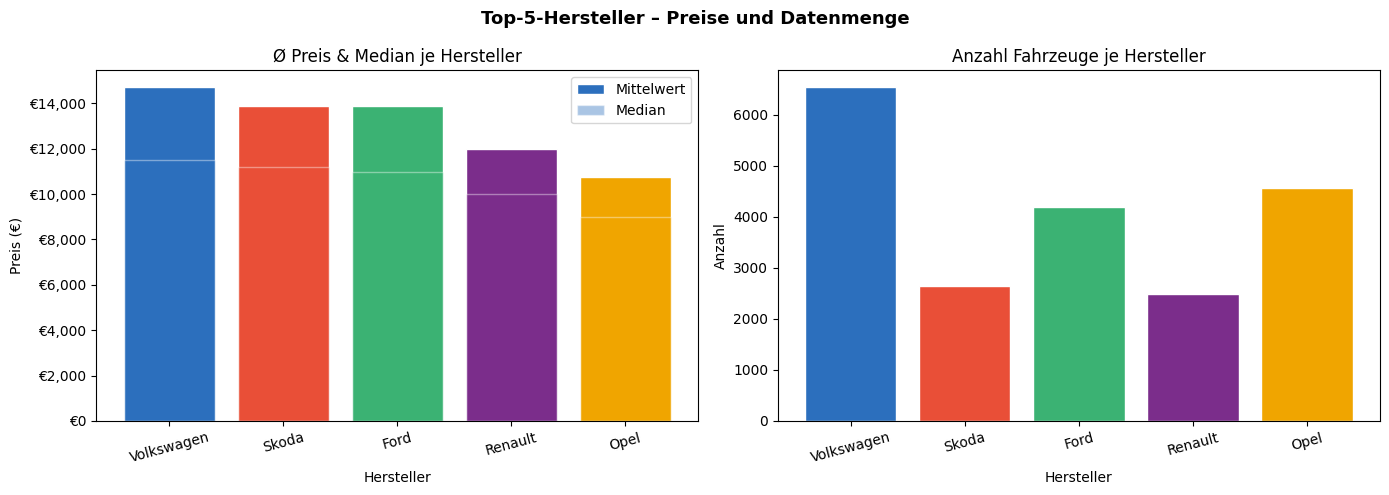

In [9]:
# Visuelle Darstellung des Preisunterschiedes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

make_order = avg_stats.sort_values('mean', ascending=False).index.tolist()
colors = ['#2c6fbd','#e94f37','#3bb273','#7b2d8b','#f0a500']

# Mittelwert
axes[0].bar(make_order, avg_stats.loc[make_order, 'mean'], color=colors, edgecolor='white')
axes[0].bar(make_order, avg_stats.loc[make_order, 'median'],
            color=colors, alpha=0.4, edgecolor='white', label='Median')
axes[0].set_title('Ø Preis & Median je Hersteller')
axes[0].set_ylabel('Preis (€)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{int(v):,}'))
axes[0].legend(['Mittelwert', 'Median'], loc='upper right')

# Anzahl
axes[1].bar(make_order, avg_stats.loc[make_order, 'count'], color=colors, edgecolor='white')
axes[1].set_title('Anzahl Fahrzeuge je Hersteller')
axes[1].set_ylabel('Anzahl')

for ax in axes:
    ax.set_xlabel('Hersteller')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Top-5-Hersteller – Preise und Datenmenge', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Features & Train/Test-Split

# Phase‑4‑Feature‑Set
feature_cols = ["hp", "mileage", "car_age", "fuel", "gear"]
target_col = "price_log"

X = df_top5[feature_cols]
y = df_top5[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline speziell für die ausgewählten ML-Modelle
numeric_features = ["hp", "mileage", "car_age"]
categorical_features = ["fuel", "gear"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor_phase4 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Baseline-Modell (Durchschnitt)

baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("\nBaseline (Durchschnittsmodell):")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")



Baseline (Durchschnittsmodell):
MAE:  0.4292
RMSE: 0.5160
R²:   -0.0003


&rarr; Baseline erwartbar schlecht. 

**Ein gutes Modell sollte:**
- MAE < 0.20
- RMSE < 0.30
- R² > 0.70

In [11]:
# Lineare Regression

linreg_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor_phase4),   # <--- NEU
        ("model", LinearRegression())
    ]
)

linreg_pipe.fit(X_train, y_train)
linreg_pred = linreg_pipe.predict(X_test)

linreg_mae = mean_absolute_error(y_test, linreg_pred)
linreg_rmse = np.sqrt(mean_squared_error(y_test, linreg_pred))
linreg_r2 = r2_score(y_test, linreg_pred)

# Weitere Modelle

models = {
    "LinearRegression": LinearRegression(),
    "CatBoost": CatBoostRegressor(
        depth=8, learning_rate=0.1, iterations=500, verbose=False
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor_phase4),   # <--- NEU
            ("model", model),
        ]
    )
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("RMSE")
print(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print(f"\nBestes Modell: {best_model_name}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 16364, number of used features: 11
[LightGBM] [Info] Start training from score 9.347435


c:\Users\eiend\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


              model       MAE      RMSE        R2
1          CatBoost  0.119864  0.156183  0.908368
3           XGBoost  0.120469  0.157454  0.906871
2          LightGBM  0.121012  0.158296  0.905872
0  LinearRegression  0.151760  0.196257  0.855314

Bestes Modell: CatBoost


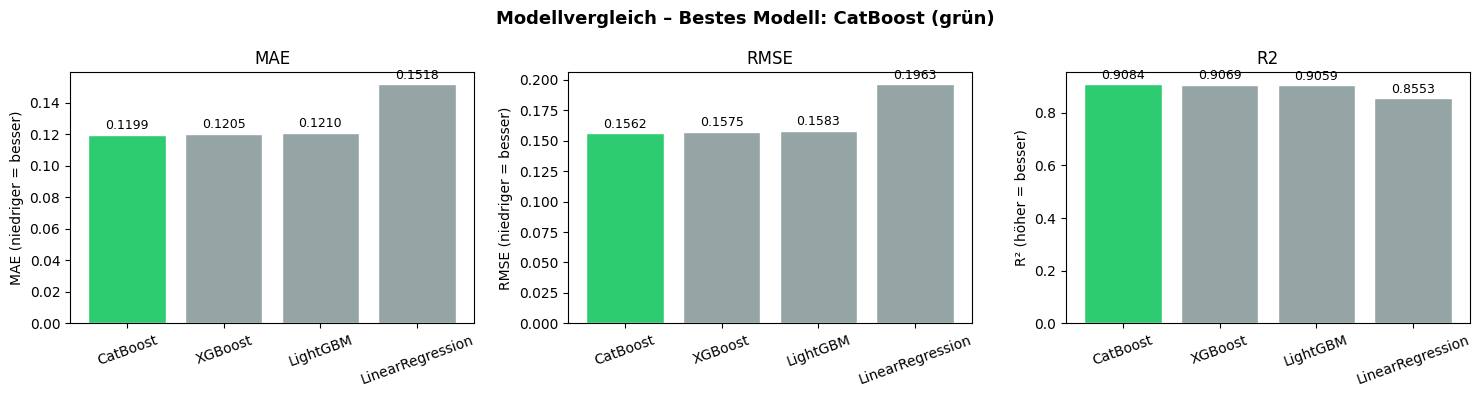

In [12]:
# Visuelle Darstellung des Unterschiedes zwischen CatBoost und Linearer Regression

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_order = results_df.sort_values('R2', ascending=False)['model'].tolist()
palette = ['#2ecc71' if m == best_model_name else '#95a5a6' for m in model_order]

for ax, metric, better, ylabel in [
    (axes[0], 'MAE',  'lower', 'MAE (niedriger = besser)'),
    (axes[1], 'RMSE', 'lower', 'RMSE (niedriger = besser)'),
    (axes[2], 'R2',   'higher','R² (höher = besser)'),
]:
    vals = [results_df.loc[results_df['model']==m, metric].values[0] for m in model_order]
    bars = ax.bar(model_order, vals, color=palette, edgecolor='white')
    ax.set_title(f'{metric}')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    # Wert über jedem Balken
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(f'Modellvergleich – Bestes Modell: {best_model_name} (grün)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# Feature Importance 

if best_model_name in ["CatBoost", "LightGBM", "XGBoost"]:
    print("\nFeature Importances:")

    # Modell extrahieren
    model = best_model.named_steps["model"]

    # Feature-Namen nach Preprocessing extrahieren
    ohe = best_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["encoder"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)

    all_feature_names = numeric_features + list(cat_feature_names)

    # Importances holen
    if best_model_name == "CatBoost":
        importances = model.get_feature_importance()
    else:
        importances = model.feature_importances_

    # DataFrame bauen
    fi = pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    })

    print(fi.sort_values("importance", ascending=False))



Feature Importances:
                   feature  importance
0                       hp   47.901731
2                  car_age   24.541762
1                  mileage   18.639620
5              fuel_Diesel    3.237041
14             gear_Manual    2.209303
10           fuel_Gasoline    1.643380
13          gear_Automatic    1.428114
6            fuel_Electric    0.220852
8   fuel_Electric/Gasoline    0.090169
4                 fuel_CNG    0.055592
15     gear_Semi-automatic    0.012108
11                fuel_LPG    0.008457
12             fuel_Others    0.005444
7     fuel_Electric/Diesel    0.003212
3          fuel_-/- (Fuel)    0.002860
9             fuel_Ethanol    0.000356


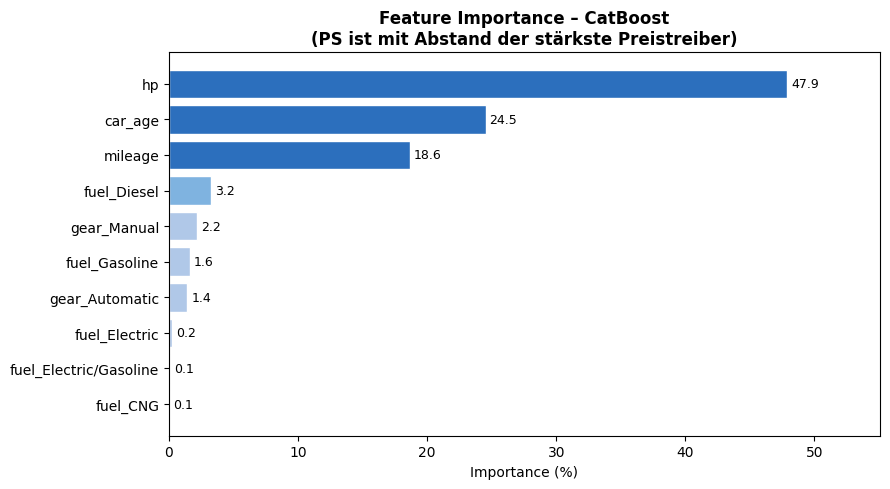

In [15]:
# Visualisierung: PS als das wichtigste Feature
fi_plot = fi.sort_values('importance', ascending=True).tail(10)  # Top 10

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2c6fbd' if imp > 10 else '#7fb3e0' if imp > 3 else '#b0c8e8'
          for imp in fi_plot['importance']]

ax.barh(fi_plot['feature'], fi_plot['importance'], color=colors, edgecolor='white')

# Werte rechts am Balken
for i, (val, name) in enumerate(zip(fi_plot['importance'], fi_plot['feature'])):
    ax.text(val + 0.3, i, f'{val:.1f}', va='center', fontsize=9)

ax.set_xlabel('Importance (%)')
ax.set_title(f'Feature Importance – {best_model_name}\n(PS ist mit Abstand der stärkste Preistreiber)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, fi_plot['importance'].max() * 1.15)
plt.tight_layout()
plt.show()


# Validierung und Interpretation der Ergebnisse

## **1. Modellgüte**
Das beste Modell ist **CatBoost** mit:

- **MAE ≈ 0.12**  
- **RMSE ≈ 0.156**  
- **R² ≈ 0.91**

Damit erklärt das Modell rund **91 % der Preisvarianz** der Fahrzeuge in den Top‑5‑Herstellern.  
Die Fehlerwerte entsprechen im realen Preisraum etwa **±12–15 %**, was für Gebrauchtwagenpreise ein sehr gutes Ergebnis ist.  
Alle Boosting‑Modelle (CatBoost, XGBoost, LightGBM) liegen eng beieinander, was die Robustheit der Ergebnisse bestätigt.

Die lineare Regression ist deutlich schwächer (R² ≈ 0.85), schlägt aber die Baseline klar.  
Damit ist die Modellwahl gut begründet.

---

## **2. Validierung über Feature Importance**
Die Feature‑Importance‑Analyse zeigt ein **logisch nachvollziehbares Muster**, das gut zu realen Marktmechanismen passt:

### **Wichtigste Einflussfaktoren**
1. **PS (hp)** – *47.9 %*  
   &rarr; Leistung ist der stärkste Preistreiber. Fahrzeuge mit höherer Motorleistung erzielen systematisch höhere Preise.

2. **Alter (car_age)** – *24.5 %*  
   &rarr; Je jünger das Fahrzeug, desto höher der Preis. Der starke Einfluss bestätigt die Relevanz des Alters als Wertverlustfaktor.

3. **Kilometerstand (mileage)** – *18.6 %*  
   &rarr; Ein höherer Kilometerstand reduziert den Preis. Der Einfluss ist etwas geringer als bei Alter und PS, aber immer noch sehr deutlich.

#### **Mittlere Bedeutung**
4. **Kraftstoffart (fuel)** – *insgesamt ca. 5–6 %*  
   &rarr; Diesel und Benzin haben den größten Einfluss.  
   &rarr; Alternative Antriebe (Elektro, CNG, LPG) spielen eine kleinere Rolle, was zur geringeren Marktverbreitung passt.

#### **Geringe Bedeutung**
5. **Getriebe (gear)** – *ca. 3–4 %*  
   &rarr; Automatik/Manuell beeinflusst den Preis, aber deutlich weniger als technische Fahrzeugmerkmale.

---

### **Plausibilitätscheck**
Die Feature‑Importances sind **vollständig plausibel**:

- Technische Kernmerkmale (PS, Alter, Kilometerstand) dominieren &rarr; realistisch  
- Kraftstoffart und Getriebe haben Einfluss, aber deutlich weniger &rarr; realistisch  
- Keine unlogischen Ausreißer &rarr; Modell verhält sich stabil  
- Die Reihenfolge entspricht typischen Marktmechanismen im Gebrauchtwagenhandel.  

Damit ist das Modell **inhaltlich valide**.

---

### **Gesamtinterpretation**
Das Modell zeigt:

- Der Preis wird primär durch **Leistung, Alter und Laufleistung** bestimmt.  
- Kategorien wie Kraftstoff und Getriebe spielen eine **untergeordnete, aber sinnvolle** Rolle.  
- CatBoost ist das beste Modell, weil es **nichtlineare Zusammenhänge** und **kategoriale Variablen** besonders gut verarbeitet.  
- Die Ergebnisse sind **stabil, plausibel und gut interpretierbar**.

## **3. Residuenanalyse**

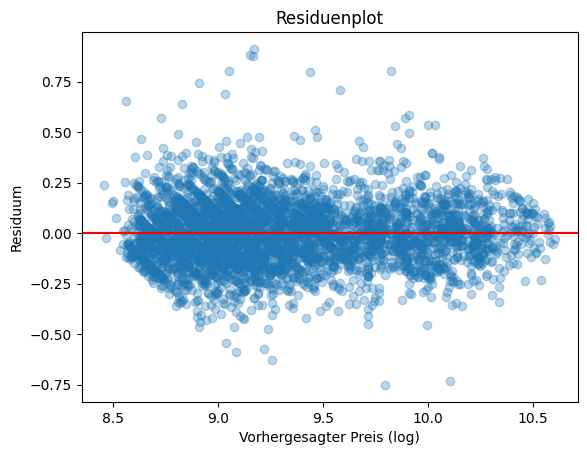

In [16]:
# Residuen berechnen

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# Residuenplot
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Vorhergesagter Preis (log)")
plt.ylabel("Residuum")
plt.title("Residuenplot")
plt.show()


**Der Plot zeigt:**
- Die Punkte liegen zufällig um die 0‑Linie &rarr; kein Muster
- Keine „Trichterform“ &rarr; keine starke Heteroskedastizität
- Leichte Streuung bei hohen Preisen &rarr; teure Autos schwerer vorherzusagen

**Folglich:**

Die Residuen streuen zufällig, ohne systematische Muster. <br>
Das Modell ist stabil und generalisiert gut.

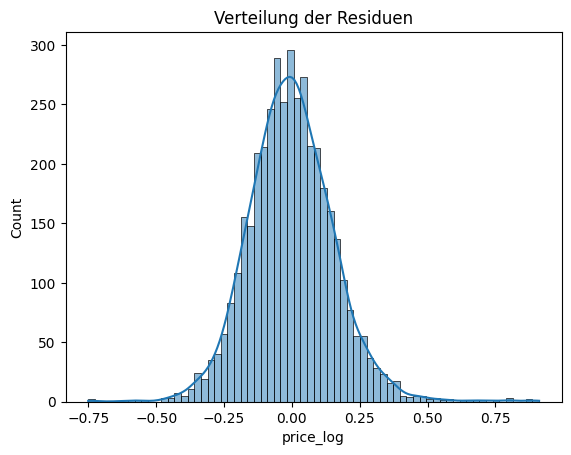

In [17]:
# Fehlerverteilung

sns.histplot(residuals, kde=True)
plt.title("Verteilung der Residuen")
plt.show()


**Der Plot zeigt:**
- Die Verteilung ist annähernd symmetrisch.
- Leichter „Fat Tail“ rechts &rarr; teure Autos werden eher unterschätzt

**Folglich:**
Die Fehlerverteilung ist symmetrisch, mit wenigen Ausreißern im oberen Preisbereich.

### Gesamtinterpretation

Die Residuenanalyse dient dazu zu prüfen, ob das Modell systematische Fehler macht oder bestimmte Muster in den Vorhersagefehlern erkennbar sind.
Die Residuen (Differenz zwischen vorhergesagtem und tatsächlichem Preis) zeigen eine weitgehend zufällige Streuung ohne klare Struktur. Dies deutet darauf hin, dass das Modell die zugrunde liegenden Zusammenhänge gut erfasst und keine offensichtlichen Verzerrungen vorliegen.

Die Fehlerverteilung ist annähernd symmetrisch, mit einem leichten „Fat‑Tail“ im oberen Preisbereich. Das bedeutet, dass besonders teure Fahrzeuge etwas häufiger unterschätzt werden – ein typisches Verhalten bei Modellen, die auf log‑transformierten Preisen trainiert wurden.
Insgesamt zeigt die Residuenanalyse ein stabiles und gut generalisierendes Modell ohne starke Heteroskedastizität oder systematische Abweichungen.

## **4. Fehleranalyse**

In [18]:
# Fehleranalyse

error_df = df_top5.loc[y_test.index].copy()
error_df["pred"] = y_pred
error_df["residual"] = residuals
error_df["abs_error"] = abs(residuals)

error_df.sort_values("abs_error", ascending=False).head(10)

,mileage,make,model,fuel,gear,offerType,price,hp,year,price_log,car_age,pred,residual,abs_error
17006,188590,Volkswagen,T6 Multivan,Diesel,Manual,Used,23900,150.0,2015,10.081634,7,9.170382,0.911251,0.911251
17407,214477,Volkswagen,T5 Multivan,Diesel,Manual,Used,22777,114.0,2013,10.033507,9,9.151122,0.882384,0.882384
16067,111000,Volkswagen,T5 Multivan,Diesel,Manual,Used,22999,140.0,2011,10.043206,11,9.167082,0.876124,0.876124
27028,100,Renault,ZOE,Electric,Automatic,Pre-registered,41195,69.0,2020,10.626072,2,9.823515,0.802557,0.802557
14370,156000,Volkswagen,Caddy,Diesel,Automatic,Used,18999,140.0,2011,9.852142,11,9.051496,0.800646,0.800646
20362,49000,Ford,Transit,Diesel,Manual,Used,27900,125.0,2014,10.236382,8,9.438305,0.798077,0.798077
10252,110000,Opel,Zafira,Diesel,Automatic,Used,8480,170.0,2019,9.045466,3,9.796321,-0.750855,0.750855
36668,190000,Volkswagen,Amarok,Diesel,Manual,Used,15600,163.0,2013,9.655026,9,8.911128,0.743898,0.743898
44716,2727,Renault,Twingo,Electric,Automatic,Demonstration,11780,42.0,2020,9.374158,2,10.105764,-0.731606,0.731606
39307,149550,Volkswagen,T5 Multivan,Diesel,Automatic,Used,29446,179.0,2015,10.290313,7,9.583550,0.706763,0.706763


In [19]:
error_df.sort_values("abs_error", ascending=False).tail(10)

,mileage,make,model,fuel,gear,offerType,price,hp,year,price_log,car_age,pred,residual,abs_error
29763,19800,Skoda,Citigo,Gasoline,Manual,Used,9450,60.0,2019,9.153770,3,9.154210,-0.000440,0.000440
11383,10,Renault,Twingo,Gasoline,Manual,Pre-registered,12470,65.0,2021,9.431081,1,9.431511,-0.000429,0.000429
26129,41908,Ford,S-Max,Diesel,Automatic,Used,24650,179.0,2017,10.112532,5,10.112738,-0.000206,0.000206
41381,68358,Renault,Megane,Diesel,Manual,Used,11990,110.0,2017,9.391828,5,9.392019,-0.000190,0.000190
362,32900,Volkswagen,Passat Alltrack,Diesel,Automatic,Used,29990,190.0,2018,10.308619,4,10.308507,0.000112,0.000112
28793,61500,Ford,Focus,Gasoline,Manual,Used,7599,101.0,2013,8.935772,9,8.935866,-0.000094,0.000094
9333,98424,Volkswagen,Golf Sportsvan,Diesel,Automatic,Used,13890,150.0,2014,9.538924,8,9.539015,-0.000091,0.000091
32133,7376,Volkswagen,Golf,Gasoline,Automatic,Employee's car,26990,150.0,2020,10.203222,2,10.203174,0.000048,0.000048
33415,21840,Ford,S-Max,Diesel,Automatic,Employee's car,36339,241.0,2020,10.500647,2,10.500630,0.000017,0.000017
27691,100,Volkswagen,Tiguan,Gasoline,Manual,Pre-registered,26699,150.0,2021,10.192381,1,10.192370,0.000011,0.000011


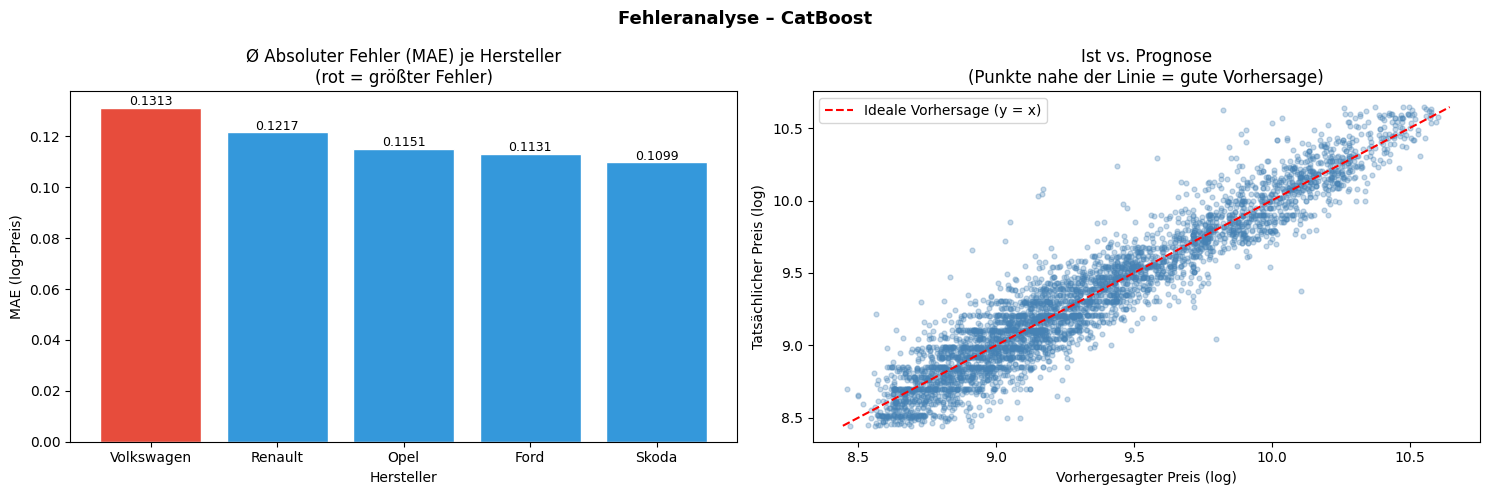

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: MAE je Hersteller 
make_errors = (
    error_df.groupby('make')['abs_error']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
make_order = make_errors['make'].tolist()
palette = ['#e74c3c' if e == make_errors['abs_error'].max() else '#3498db'
           for e in make_errors['abs_error']]

axes[0].bar(make_order, make_errors['abs_error'], color=palette, edgecolor='white')
axes[0].set_title('Ø Absoluter Fehler (MAE) je Hersteller\n(rot = größter Fehler)')
axes[0].set_xlabel('Hersteller')
axes[0].set_ylabel('MAE (log-Preis)')
for i, val in enumerate(make_errors['abs_error']):
    axes[0].text(i, val + 0.001, f'{val:.4f}', ha='center', fontsize=9)

# Plot 2: Ist vs. Prognose
axes[1].scatter(error_df['pred'], error_df['price_log'],
                alpha=0.3, s=12, color='steelblue')
# Ideale Linie (y = x)
lims = [min(error_df['pred'].min(), error_df['price_log'].min()),
        max(error_df['pred'].max(), error_df['price_log'].max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Ideale Vorhersage (y = x)')
axes[1].set_xlabel('Vorhergesagter Preis (log)')
axes[1].set_ylabel('Tatsächlicher Preis (log)')
axes[1].set_title('Ist vs. Prognose\n(Punkte nahe der Linie = gute Vorhersage)')
axes[1].legend()

plt.suptitle(f'Fehleranalyse – {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

Die größten Vorhersagefehler treten bei Fahrzeugen mit hohem Preisniveau, seltenen Kraftstoffarten oder ungewöhnlichen Konfigurationen auf.
Diese Fahrzeuge sind im Datensatz weniger häufig vertreten, wodurch das Modell weniger Beispiele zum Lernen hat.
Fahrzeuge im mittleren Preisbereich werden dagegen sehr zuverlässig vorhergesagt.
Insgesamt zeigt das Modell keine systematischen Verzerrungen gegenüber bestimmten Herstellern, sondern hat Schwierigkeiten in datenarmen Randbereichen.

**Grenzen des Modells:**
- Teure Autos &rarr; schwerer vorherzusagen
- Seltene Kraftstoffarten &rarr; größere Fehler
- Ungewöhnliche Konfigurationen &rarr; wenig Trainingsdaten
- Normale Autos &rarr; sehr gute Vorhersagen

### Gesamtinterpretation

Die detaillierte Fehleranalyse zeigt, dass die größten Vorhersagefehler bei Fahrzeugen mit extremen Eigenschaften auftreten, insbesondere bei sehr hohen Preisen, ungewöhnlichen Kraftstoffarten (z. B. CNG, LPG, Elektro‑Hybrid‑Kombinationen) oder seltenen Konfigurationen. Diese Fahrzeuge sind im Datensatz weniger häufig vertreten, wodurch das Modell weniger Beispiele zum Lernen hat.

Fahrzeuge im „normalen“ Preisbereich werden dagegen sehr zuverlässig vorhergesagt. Es gibt keine Hinweise auf systematische Benachteiligung bestimmter Hersteller oder Getriebearten.Die Fehlvorhersagen sind somit vor allem auf Datenknappheit in Randbereichen und natürliche Preisvariabilität im Gebrauchtwagenmarkt zurückzuführen.

Insgesamt bestätigt die Fehleranalyse, dass das Modell robust arbeitet und seine Schwächen dort liegen, wo auch menschliche Preisabschätzungen naturgemäß unsicherer werden.

# Export der CSV-Datei

In [16]:
# error_df exportieren

error_df.to_csv("../data/autoscout24_cleaned.csv", index=False, encoding="utf-8", decimal=",")
print("CSV-Datei erfolgreich gespeichert.")

CSV-Datei erfolgreich gespeichert.


In [17]:
# Modellvergleich exportieren

results_df.to_csv("../data/modellvergleich.csv", index=False, decimal=",")
print("Modellvergleich als CSV-Datei gespeichert.")


Modellvergleich als CSV-Datei gespeichert.


In [18]:
# Feature Importance exportieren

fi.to_csv("../data/feature_importance.csv", index=False, decimal=",")
print("Feature Importance als CSV-Datei gespeichert.")

Feature Importance als CSV-Datei gespeichert.


# Tableau-Aggregationen

In [23]:
from pathlib import Path
import statistics as st

OUTPUT_DIR = Path('../data/tableau_exports')
OUTPUT_DIR.mkdir(exist_ok=True)

# Anzahl Fahrzeuge je Hersteller
make_counts_df = (
    df_top5['make'].value_counts()
    .reset_index()
    .rename(columns={'make': 'Make', 'count': 'Count'})
)
make_counts_df.to_csv(OUTPUT_DIR / 'make_counts.csv', index=False)

# Durchschnittlicher Preis nach Jahr & Hersteller 
price_year = (
    df_top5.groupby(['year', 'make'], as_index=False)['price']
    .agg(Avg_Price='mean', Count='count')
    .rename(columns={'year': 'Year', 'make': 'Make'})
)
price_year['Avg_Price'] = price_year['Avg_Price'].round(0)
price_year.to_csv(OUTPUT_DIR / 'price_by_year_make.csv', index=False)

# Durchschnitts- & Median-Preis je Hersteller 
avg_price_df = (
    df_top5.groupby('make', as_index=False)['price']
    .agg(Avg_Price='mean', Median_Price='median')
    .rename(columns={'make': 'Make'})
)
avg_price_df[['Avg_Price','Median_Price']] = avg_price_df[['Avg_Price','Median_Price']].round(0)
avg_price_df.to_csv(OUTPUT_DIR / 'avg_price_make.csv', index=False)

# Perzentile je Hersteller (für Box-Plot-Tooltips) 
def pct(q): return lambda x: x.quantile(q)

price_pct = (
    df_top5.groupby('make', as_index=False)['price']
    .agg(
        Min  =('min'),
        P25  =(pct(0.25)),
        Median=('median'),
        P75  =(pct(0.75)),
        P90  =(pct(0.90)),
        Max  =('max'),
        Count=('count')
    )
    .rename(columns={'make': 'Make'})
)
price_pct[['Min','P25','Median','P75','P90','Max']] = price_pct[['Min','P25','Median','P75','P90','Max']].round(0)
price_pct.to_csv(OUTPUT_DIR / 'price_percentiles_make.csv', index=False)

# Wertverlust nach Fahrzeugalter & Hersteller 
price_age = (
    df_top5.groupby(['car_age', 'make'], as_index=False)['price']
    .agg(Avg_Price='mean', Count='count')
    .rename(columns={'car_age': 'Car_Age', 'make': 'Make'})
    .query('Count >= 5')
)
price_age['Avg_Price'] = price_age['Avg_Price'].round(0)
price_age.to_csv(OUTPUT_DIR / 'price_by_age_make.csv', index=False)

# Feature Importance (lesbare Labels)
label_map = {
    'hp': 'Leistung (PS)', 'car_age': 'Fahrzeugalter',
    'mileage': 'Kilometerstand', 'fuel_Diesel': 'Kraftstoff: Diesel',
    'gear_Manual': 'Getriebe: Manuell', 'fuel_Gasoline': 'Kraftstoff: Benzin',
    'gear_Automatic': 'Getriebe: Automatik', 'fuel_Electric': 'Kraftstoff: Elektro',
}
fi_export = (
    fi[fi['feature'].isin(label_map)]
    .assign(Label=lambda x: x['feature'].map(label_map))
    .rename(columns={'feature': 'Feature', 'importance': 'Importance'})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
fi_export.to_csv(OUTPUT_DIR / 'feature_importance_clean.csv', index=False, decimal=",")

# Modellvergleich 
modell_export = results_df.copy().rename(columns={'model': 'Model'})
modell_export[['MAE','RMSE','R2']] = modell_export[['MAE','RMSE','R2']].round(4)
modell_export['Best'] = modell_export['R2'] == modell_export['R2'].max()
modell_export.to_csv(OUTPUT_DIR / 'modellvergleich_clean.csv', index=False)

print("Alle Tableau-CSVs gespeichert:")
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    rows = sum(1 for _ in open(f)) - 1
    print(f"  {f.name:<40} ({rows} Zeilen)")


Alle Tableau-CSVs gespeichert:
  avg_price_make.csv                       (5 Zeilen)
  feature_importance_clean.csv             (8 Zeilen)
  make_counts.csv                          (5 Zeilen)
  modellvergleich_clean.csv                (4 Zeilen)
  price_by_age_make.csv                    (55 Zeilen)
  price_by_year_make.csv                   (55 Zeilen)
  price_percentiles_make.csv               (5 Zeilen)
